# 08 · 비지도 구조 탐색 — 숨은 패턴이 있는가?

> Part 8 · *지도학습이 신호를 못 찾았다. 그렇다면 레이블 없이도 드러나는 '숨은 군집'은 없을까?*

비지도 학습은 타깃 없이 데이터 **자체의 구조**를 찾습니다. 세 가지 고전 도구를 회차의 모양 특성
(합계·홀짝·고저·범위·연속·AC·십분위)에 적용합니다.

- **PCA** — 몇 개 성분이 분산 대부분을 설명하나? (저차원 다양체 vs 잡음)
- **k-means + 실루엣** — 잘 분리된 군집이 존재하는 k가 있나? (실루엣≈0이면 없음)
- **DBSCAN** — 밀도 기반 군집; 무작위면 하나의 덩어리로 뭉침
- **t-SNE** — 국소 구조를 *과장*하는 2D 시각화; 구조 없으면 균질한 구름

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.lotto_ds import viz, unsupervised as un

viz.apply_style()

## 1. PCA — 분산은 평평하게 퍼져 있다
뚜렷한 주성분이 없다는 것은 데이터가 저차원 구조 없이 여러 방향으로 고르게 흩어져 있다는 뜻입니다.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


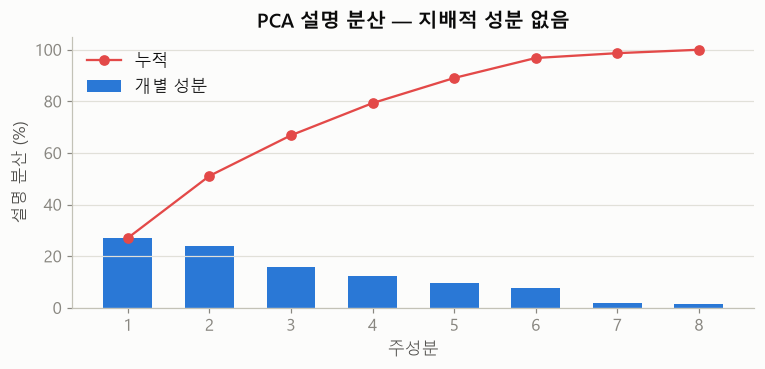

제1성분 27.1% · 상위 2개 누적 51.1% (구조가 있다면 몇 성분이 대부분을 설명해야 함)


In [2]:
pca = un.pca_analysis()
evr = np.array(pca["explained_variance_ratio"])
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(range(1, len(evr)+1), evr*100, color=viz.CAT[0], width=0.6, label="개별 성분")
ax.plot(range(1, len(evr)+1), np.cumsum(evr)*100, "o-", color=viz.CAT[5], label="누적")
ax.set_title("PCA 설명 분산 — 지배적 성분 없음")
ax.set_xlabel("주성분"); ax.set_ylabel("설명 분산 (%)"); ax.legend(frameon=False)
viz.savefig(fig, "08_pca.png"); plt.show()
print(f"제1성분 {evr[0]*100:.1f}% · 상위 2개 누적 {np.cumsum(evr)[1]*100:.1f}% "
      f"(구조가 있다면 몇 성분이 대부분을 설명해야 함)")

## 2. k-means 실루엣 — 어떤 k도 좋은 군집을 만들지 못한다
실루엣 점수는 -1~1이며, 0.5 이상이면 뚜렷한 군집, 0 근처면 군집 없음을 뜻합니다.

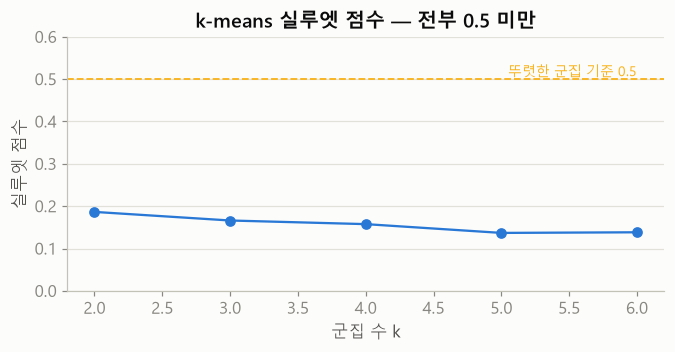

최고 실루엣 0.187 (k=2) — 의미 있는 군집 없음


In [3]:
km = un.kmeans_silhouettes()
ks = list(km["silhouettes"].keys()); sc = list(km["silhouettes"].values())
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(ks, sc, "o-", color=viz.CAT[0], ms=6)
ax.axhline(0.5, ls="--", color=viz.STATUS["warning"], lw=1.2)
ax.text(ks[-1], 0.5, " 뚜렷한 군집 기준 0.5", color=viz.STATUS["warning"], fontsize=9, va="bottom", ha="right")
ax.set_ylim(0, 0.6)
ax.set_title("k-means 실루엣 점수 — 전부 0.5 미만")
ax.set_xlabel("군집 수 k"); ax.set_ylabel("실루엣 점수")
viz.savefig(fig, "08_silhouette.png"); plt.show()
print(f"최고 실루엣 {km['best_score']:.3f} (k={km['best_k']}) — 의미 있는 군집 없음")

## 3. t-SNE — 하나의 균질한 구름
시간(회차)으로 색을 입혀 봅니다. 시간에 따른 군집/이동이 있다면 색이 뭉치겠지만, 실제로는 고르게 섞입니다.

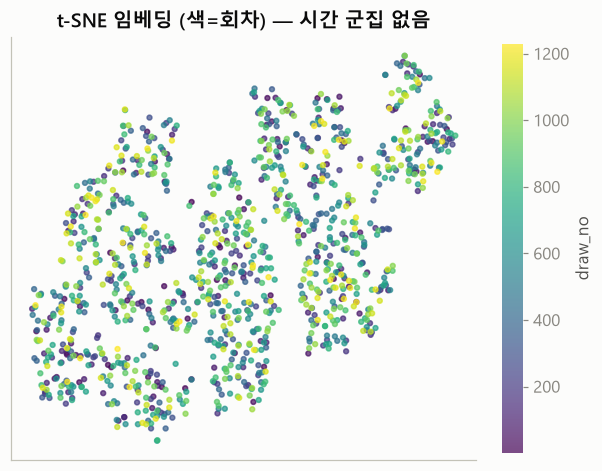

In [4]:
emb = un.tsne_embedding()
from src.lotto_ds.features import draw_features
feat = draw_features()
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(emb[:,0], emb[:,1], c=feat["draw_no"], cmap="viridis", s=10, alpha=0.7)
ax.set_title("t-SNE 임베딩 (색=회차) — 시간 군집 없음")
ax.set_xticks([]); ax.set_yticks([])
cb = fig.colorbar(sc, ax=ax, fraction=0.04); cb.set_label("draw_no"); cb.outline.set_visible(False)
viz.savefig(fig, "08_tsne.png"); plt.show()

⚠️ **흔한 함정**: t-SNE/PCA 그림에서 사람 눈은 없는 군집을 *만들어냅니다*. 그래서 시각화만 믿지 말고
**실루엣 같은 정량 지표**로 검증해야 합니다. 또 t-SNE의 군집 크기·거리는 해석하면 안 됩니다.

### 정리
- PCA 평평 · 실루엣≈0.19(≪0.5) · t-SNE 균질 구름 — 활용할 숨은 구조 없음.
- 지도·비지도 모두 "예측 가능한 구조 없음"으로 수렴.
- 다음: **09 · 백테스트 & 최종 결론** — 모든 전략을 한 판에서 겨루게 한다.